In [13]:
%%bash
set -e
mkdir -p outputs tmp_ndl
echo "ready."

ready.


In [ ]:
%%bash
set -euo pipefail

cat > ndl_union_by_id.R << 'RS'
suppressWarnings({ library(httr); library(xml2); library(readr); library(dplyr); library(stringi) })
dir.create("outputs", showWarnings = FALSE)

# ===== 変更可 =====
START_YEAR <- 1911
THIS_YEAR  <- as.integer(format(Sys.Date(), "%Y"))
YEARS      <- START_YEAR:THIS_YEAR

OS_URL    <- "https://ndlsearch.ndl.go.jp/api/opensearch"
PER_PAGE  <- 100     # NDL OpenSearchは100ページまで
PAGES_MAX <- 80      # ページ数
PAUSE     <- 0.25    # スピード

# キーワード（補充可）
NIHONBASHI <- c("日本橋","日本桥","にほんばし","ニホンバシ","Nihonbashi")
NIHONBASHI_RIVER  <- c("日本橋川","日本桥川", "にほんばしがわ", "ニホンバシガワ", "Nihonbashi-gawa", "舟運", "魚河岸", "河岸", "Water transport", "船着場", "発着場", "canal","waterway", "Nihonbashi gawa",
             "waterfront","quay","Nihonbashi River","Nihonbashi river side","river cruise","boat")
ELEVEDS <- c("首都高","首都高速","高架","高速道路", "首都高日本橋", "高速", "高架橋", "都心環状線", "環状線", "日本橋区間", "Inner Circular Route", "metropolitan expressway", "Shuto Expressway","Shutoko","expressway","elevated","viaduct","overpass","under expressway")

ua <- user_agent("NDL-UnionByID/1.0 (+https://ndlsearch.ndl.go.jp/)")

# 二重カウント排除
fetch_ids_one <- function(q, y, idx){
  res <- GET(OS_URL, query=list(any=q,
                                from=sprintf("%d-01-01", y),
                                until=sprintf("%d-12-31", y),
                                cnt=PER_PAGE, idx=idx), ua)
  if (http_error(res)) return(character())
  doc <- tryCatch(read_xml(content(res, "raw")), error=function(e) NULL)
  if (is.null(doc)) return(character())
  items <- xml_find_all(doc, "//*[local-name()='item']")
  if (length(items)==0) return(character())
  ids <- character()
  for (it in items){
    link <- xml_text(xml_find_first(it, "./*[local-name()='link']"))
    if (is.na(link) || link==""){
      link <- xml_text(xml_find_first(it, "./*[local-name()='guid']"))
    }
    if (!is.na(link) && nzchar(link)) ids <- c(ids, link)
  }
  unique(ids)
}

# カウントされた数を集計
fetch_ids_query_year <- function(q, y){
  all <- character()
  for (p in 1:PAGES_MAX){
    idx <- (p-1)*PER_PAGE + 1
    ids <- fetch_ids_one(q, y, idx)
    if (length(ids)==0) break
    all <- unique(c(all, ids))
    if (length(ids) < PER_PAGE) break
    Sys.sleep(PAUSE)
  }
  all
}

# 分母： NIHONBASHI
collect_bridge_year <- function(y){
  all <- character()
  for (b in NIHONBASHI){
    ids <- fetch_ids_query_year(b, y)
    all <- unique(c(all, ids))
  }
  all
}

# 分子A：NIHONBSHI×NIHONBASHI RIVER
collect_A_year <- function(y){
  all <- character()
  for (b in NIHONBASHI) for (r in NIHONBASHI_RIVER){
    ids <- fetch_ids_query_year(paste(b, r), y)
    all <- unique(c(all, ids))
  }
  all
}

# 分子B：NIHONBASHI×ELEVEDS
collect_B_year <- function(y){
  all <- character()
  for (b in NIHONBASHI) for (e in ELEVEDS){
    ids <- fetch_ids_query_year(paste(b, e), y)
    all <- unique(c(all, ids))
  }
  all
}

rows <- list()
for (y in YEARS){
  cat("Year", y, "...\n")
  setBridge <- collect_bridge_year(y)
  setA      <- collect_A_year(y)
  setB      <- collect_B_year(y)
  rows[[length(rows)+1]] <- data.frame(
    year=y,
    denom_bridge=length(setBridge),
    num_A=length(setA),
    num_B=length(setB)
  )
}

out <- bind_rows(rows) %>% arrange(year)
write_csv(out, "outputs/ndl_popular_yearly.csv")
cat("Wrote outputs/ndl_popular_yearly.csv\n")
print(tail(out, 8))
RS

Rscript ndl_union_by_id.R
echo "---- head outputs/ndl_popular_yearly.csv ----"
(head -n 10 outputs/ndl_popular_yearly.csv || true)

In [17]:
#check every year
%%bash
Rscript - <<'RS'
suppressWarnings({ library(readr) })
d <- read_csv("outputs/ndl_popular_yearly.csv", show_col_types=FALSE)

for (i in seq_len(nrow(d))) {
  cat(sprintf("%3d %4d %6d %4d %4d\n",
              i, d$year[i], d$denom_bridge[i], d$num_A[i], d$num_B[i]))
}
RS

  1 1911     78    4    1
  2 1912     63    1    0
  3 1913     59    0    0
  4 1914     66    1    1
  5 1915     61    1    0
  6 1916     91    3    0
  7 1917     43    1    0
  8 1918     57    2    0
  9 1919     46    0    1
 10 1920     50    1    0
 11 1921     43    2    0
 12 1922     62    3    1
 13 1923    119    6    0
 14 1924     75    2    0
 15 1925     62    0    0
 16 1926     69    1    0
 17 1927     78    0    0
 18 1928     62    0    2
 19 1929     89    0    0
 20 1930    110    3    1
 21 1931     70    3    0
 22 1932     96    0    0
 23 1933     94    3    0
 24 1934     83    4    1
 25 1935     84    4    1
 26 1936    118    1    2
 27 1937    288    0    0
 28 1938    102    0    0
 29 1939     90    0    0
 30 1940    102    0    1
 31 1941     74    0    0
 32 1942     79    0    0
 33 1943     61    0    0
 34 1944     45    0    0
 35 1945     37    0    0
 36 1946     37    0    0
 37 1947     28    0    0
 38 1948     24    0    0
 39 1949    

In [18]:
#文献check1
%%bash
set -e
YEAR=2010
Q='%22%E6%97%A5%E6%9C%AC%E6%A9%8B%22'  # "日本橋"
echo "[OpenSearch] $YEAR 日本橋 (head 120 lines of RSS)"
curl -s --compressed -H "Accept: application/rss+xml" -A "Sampler/1.0" \
  "https://ndlsearch.ndl.go.jp/api/opensearch?any=${Q}&from=${YEAR}-01-01&until=${YEAR}-12-31&cnt=1&idx=1" \
  | sed -n '1,120p'

[OpenSearch] 2010 日本橋 (head 120 lines of RSS)
<rss xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:openSearch="http://a9.com/-/spec/opensearchrss/1.0/" xmlns:dcndl="http://ndl.go.jp/dcndl/terms/" xmlns:dcmitype="http://purl.org/dc/dcmitype/" xmlns:dcterms="http://purl.org/dc/terms/" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xmlns:rdfs="http://www.w3.org/2000/01/rdf-schema#" xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#" version="2.0">
  <channel>
    <title>"日本橋" 2010-01-01 2010-12-31 - 国立国会図書館サーチ OpenSearch</title>
    <link>https://ndlsearch.ndl.go.jp/api/opensearch?any=%22%E6%97%A5%E6%9C%AC%E6%A9%8B%22&amp;from=2010-01-01&amp;until=2010-12-31&amp;cnt=1&amp;idx=1</link>
    <description>Search results for any="日本橋" from=2010-01-01 until=2010-12-31 cnt=1 idx=1</description>
    <language>ja</language>
    <openSearch:totalResults>236</openSearch:totalResults>
    <openSearch:startIndex>1</openSearch:startIndex>
    <openSearch:itemsPerPage>1</openSearch:itemsPer

In [19]:
%%bash
set -euo pipefail

Rscript - <<'RS'
suppressWarnings({ library(readr); library(dplyr); library(tidyr) }) # Add tidyr here
dir.create("outputs", showWarnings = FALSE)

# 統計結果を読み込み
ndl <- read_csv("outputs/ndl_popular_yearly.csv", show_col_types = FALSE) %>% arrange(year)

# 1911年から現在までの完全な年次系列を用意し，欠測年の件数を 0 で補完した。各年の割合（分子÷分母）を算出する（分母が 0 の年は NA とする）。
START_YEAR <- 1911
THIS_YEAR  <- as.integer(format(Sys.Date(), "%Y"))
years      <- tibble(year = START_YEAR:THIS_YEAR)
# 移動平均：10年
ma <- function(x,k=10){ stats::filter(x, rep(1/k,k), sides=2) }

dat <- years %>%
  left_join(ndl, by="year") %>%
  mutate(across(c(denom_bridge, num_A, num_B), ~replace_na(., 0))) %>% # NA　→ 0、数値0　→　整数0
  mutate(
    prop_A      = ifelse(denom_bridge>0, num_A/denom_bridge, NA_real_),   # 日本橋&日本橋川/日本橋関連記述 比率
    prop_B      = ifelse(denom_bridge>0, num_B/denom_bridge, NA_real_),   # 日本橋&高架/日本橋関連記述 比率
    prop_A_ma3  = as.numeric(ma(prop_A, 10)),                              # 移動平均：10年
    prop_B_ma3  = as.numeric(ma(prop_B, 10))
  )

write_csv(dat, "outputs/ndl_only_timeseries.csv")
cat("✓ Wrote outputs/ndl_only_timeseries.csv\n")
print(tail(dat, 10))
RS

✓ Wrote outputs/ndl_only_timeseries.csv
# A tibble: 10 × 8
    year denom_bridge num_A num_B  prop_A   prop_B prop_A_ma3 prop_B_ma3
   <dbl>        <dbl> <dbl> <dbl>   <dbl>    <dbl>      <dbl>      <dbl>
 1  2017          349    13    24  0.0372  0.0688      0.0481     0.0460
 2  2018          364    22    30  0.0604  0.0824      0.0484     0.0463
 3  2019          400    16    28  0.04    0.07        0.0475     0.0448
 4  2020          300     9     3  0.03    0.01        0.0455     0.0437
 5  2021          335     8     3  0.0239  0.00896    NA         NA     
 6  2022          305    15    16  0.0492  0.0525     NA         NA     
 7  2023          240     9    11  0.0375  0.0458     NA         NA     
 8  2024          262     8     8  0.0305  0.0305     NA         NA     
 9  2025          233    13     8  0.0558  0.0343     NA         NA     
10  2026            0     0     0 NA      NA          NA         NA     



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



In [20]:
#Noto CJK フォント（日本語対応） を入れて有効化する
%%bash
set -e
apt-get -qq update
apt-get -qq install -y fonts-noto-cjk
fc-cache -f
fc-list | grep -E "Noto.*(CJK|JP)" | head

Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc: Noto Serif CJK SC:style=Bold
/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc: Noto Serif CJK TC:style=Bold
/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc: Noto Serif CJK JP:style=Bold
/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc: Noto Serif CJK HK:style=Bold
/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc: Noto Serif CJK KR:style=Bold
/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc: Noto Sans CJK JP:style=Regular
/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc: Noto Sans CJK HK:style=Regular
/usr/share/fonts/opentype/noto/NotoSansCJK-R

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [21]:
#0~1ver.
%%bash
set -euo pipefail
# CJK（中日韓）フォントをインストールする
apt-get -qq update
apt-get -qq install -y fonts-noto-cjk
fc-cache -f

# Install R packages
Rscript -e 'install.packages(c("showtext", "sysfonts"), repos="http://cran.rstudio.com")'


Rscript - <<'RS'
suppressWarnings({
  library(readr); library(showtext); library(sysfonts)
})

# CJK フォントファイルを直接登録する
font_file <- "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
picked <- "" # Default to empty

if (file.exists(font_file)) {
  sysfonts::font_add(family="CJK", regular=font_file)
  picked <- "CJK"
  message("Registered font from file: ", font_file)
  showtext_auto()
} else {
  message("Warning: NotoSansCJK-Regular.ttc not found at expected path. Using default system font.")
}


# データを読み込み、チャート生成
dat <- read_csv("outputs/ndl_only_timeseries.csv", show_col_types=FALSE)

main_title <- "「川」から「高架」へ：日本橋における景観イメージの転換（1911–2025）"
x_lab      <- "年"
y_lab      <- "共起率（日本橋関連記録に占める割合）"
legend_lab <- c("日本橋 & 日本橋川（A）", "日本橋 & 高架（B）")

png("outputs/ndl_only_1911_present.png", width=1200, height=720, type="cairo")
# 選択したフォントファミリーを使用し、なければデフォルトとして空文字列（""）にフォールバックする。
par(mar=c(5,6,4,1.5), family=picked)

yr <- dat$year
plot(yr, dat$prop_A_ma3, type="l", lwd=2, ylim=c(0,1),
     xlab=x_lab, ylab=y_lab, main=main_title)
lines(yr, dat$prop_B_ma3, lwd=2, lty=2)
#　縦破線
abline(v=1963, lty=3); abline(v=1958, lty=3); abline(v=1923, lty=3); abline(v=1911, lty=3); abline(v=1950, lty=3); abline(v=2002, lty=3)

# Add text labels
text(1963, 0.2, "←高架の竣工\n(1963)", pos=4, cex=0.9)     # y=垂直位置
text(1958, 0.24, "←高架建設決定\n(1958)", pos=4, cex=0.9)
text(1950, 0.3, "←モータリゼーション\nが急速に進展(1950~)", pos=4, cex=0.9)
text(1911, 0.24, "←石造橋に架け替え\n(1911)", pos=4, cex=0.9)
text(2002, 0.2, "←日本橋地区における\n首都高の再構築案を提示(2002)", pos=4, cex=0.9)
text(1923, 0.2, "←関東大震災\n(1923)", pos=4, cex=0.9)
legend("topright", legend=legend_lab, lty=c(1,2), lwd=2, bty="n")

dev.off()
cat("✓ 图已保存：outputs/ndl_only_1911_present.png，使用字体：", picked, "\n")
RS

checking for gcc... gcc
checking whether the C compiler works... yes
checking for C compiler default output file name... a.out
checking for suffix of executables... 
checking whether we are cross compiling... no
checking for suffix of object files... o
checking whether we are using the GNU C compiler... yes
checking whether gcc accepts -g... yes
checking for gcc option to accept ISO C89... none needed
checking for pkg-config... /usr/bin/pkg-config
checking whether pkg-config could find zlib... yes
checking whether pkg-config could find libpng... yes
checking whether pkg-config could find freetype2... yes
checking whether freetype2 flags work... yes
configure: creating ./config.status
config.status: creating src/Makevars
gcc -I"/usr/share/R/include" -DNDEBUG -I/usr/include/freetype2 -I/usr/include/libpng16  -I/usr/include/libpng16        -fpic  -g -O2 -ffile-prefix-map=/build/r-base-xupQTd/r-base-4.5.2=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SO

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependency ‘showtextdb’

trying URL 'http://cran.rstudio.com/src/contrib/showtextdb_3.0.tar.gz'
trying URL 'http://cran.rstudio.com/src/contrib/showtext_0.9-7.tar.gz'
trying URL 'http://cran.rstudio.com/src/contrib/sysfonts_0.8.9.tar.gz'
* installing *source* package ‘sysfonts’ ...
** this is package ‘sysfonts’ version ‘0.8.9’
** package ‘sysfonts’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘gcc (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0’
installing to /usr/local/lib/R/site-library/00LOCK-sysfonts/00new/sysfonts/libs
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** 

In [22]:
#～0.2ver.
%%bash
set -euo pipefail
# CJK（中日韓）フォントをインストールする
apt-get -qq update
apt-get -qq install -y fonts-noto-cjk
fc-cache -f

# Install R packages
Rscript -e 'install.packages(c("showtext", "sysfonts"), repos="http://cran.rstudio.com")'

Rscript - <<'RS'
suppressWarnings({
  library(readr); library(showtext); library(sysfonts)
})

# CJK フォントファイルを直接登録する
font_file <- "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
picked <- "" # Default to empty

if (file.exists(font_file)) {
  sysfonts::font_add(family="CJK", regular=font_file)
  picked <- "CJK"
  message("Registered font from file: ", font_file)
  showtext_auto()
} else {
  message("Warning: NotoSansCJK-Regular.ttc not found at expected path. Using default system font.")
}

# データを読み込み、チャート生成
dat <- read_csv("outputs/ndl_only_timeseries.csv", show_col_types=FALSE)

main_title <- "「川」から「高架」へ：日本橋における景観イメージの転換（1911–2025）"
x_lab      <- "年"
y_lab      <- "共起率（日本橋関連記録に占める割合）"
legend_lab <- c("日本橋 & 日本橋川（A）", "日本橋 & 高架（B）")

png("outputs/ndl_only_1911_present.png", width=1200, height=720, type="cairo")
par(mar=c(5,6,4,1.5), family=picked)

yr <- dat$year
plot(yr, dat$prop_A_ma3, type="l", lwd=2, ylim=c(0,0.2),  #  0〜1 → 0〜0.2
     xlab=x_lab, ylab=y_lab, main=main_title)
lines(yr, dat$prop_B_ma3, lwd=2, lty=2)

# 縦破線
abline(v=c(1911,1923,1950,1958,1963,2002,1937,1945), lty=3)

text(1963, 0.07, "←高架の竣工(1963)", pos=4, cex=0.9)
text(1958, 0.09,"←高架建設決定(1958)", pos=4, cex=0.9)
text(1950, 0.11,"←モータリゼーション\nが急速に進展(1950~)", pos=4, cex=0.9)
text(1911, 0.07,"←石造橋に架け替え\n(1911)", pos=4, cex=0.9)
text(2002, 0.11, "←日本橋地区における\n首都高の再構築案を提示(2002)", pos=4, cex=0.9)
text(1923, 0.05, "←関東大震災\n(1923)", pos=4, cex=0.9)
text(1937, 0.07, "←日中戦争開始\n出版統制が加速\n(1937)", pos=4, cex=0.9)
text(1945, 0.05, "←終戦、出版統制が解除\n(1945)", pos=4, cex=0.9)

legend("topright", legend=legend_lab, lty=c(1,2), lwd=2, bty="n")
dev.off()
cat("✓ 图已保存：outputs/ndl_only_1911_present.png，使用字体：", picked, "\n")
RS


checking for gcc... gcc
checking whether the C compiler works... yes
checking for C compiler default output file name... a.out
checking for suffix of executables... 
checking whether we are cross compiling... no
checking for suffix of object files... o
checking whether we are using the GNU C compiler... yes
checking whether gcc accepts -g... yes
checking for gcc option to accept ISO C89... none needed
checking for pkg-config... /usr/bin/pkg-config
checking whether pkg-config could find zlib... yes
checking whether pkg-config could find libpng... yes
checking whether pkg-config could find freetype2... yes
checking whether freetype2 flags work... yes
configure: creating ./config.status
config.status: creating src/Makevars
gcc -I"/usr/share/R/include" -DNDEBUG -I/usr/include/freetype2 -I/usr/include/libpng16  -I/usr/include/libpng16        -fpic  -g -O2 -ffile-prefix-map=/build/r-base-xupQTd/r-base-4.5.2=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SO

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'http://cran.rstudio.com/src/contrib/showtext_0.9-7.tar.gz'
trying URL 'http://cran.rstudio.com/src/contrib/sysfonts_0.8.9.tar.gz'
* installing *source* package ‘sysfonts’ ...
** this is package ‘sysfonts’ version ‘0.8.9’
** package ‘sysfonts’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘gcc (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0’
installing to /usr/local/lib/R/site-library/00LOCK-sysfonts/00new/sysfonts/libs
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and 

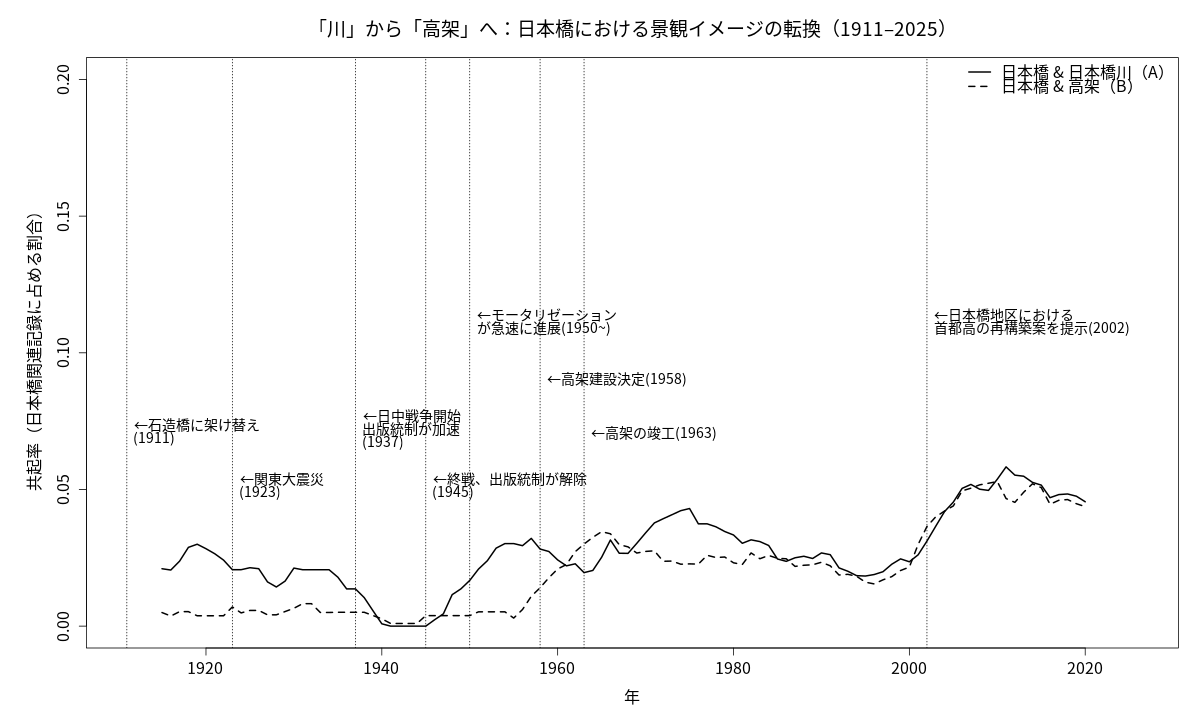

In [23]:
from IPython.display import Image, display
display(Image("outputs/ndl_only_1911_present.png"))